# 1. Load Processed Dataset

The customer-level dataset created during the data preparation phase is loaded for machine learning.

This dataset contains the engineered behavioral features, customer information, and the churn label that will be used to train and evaluate predictive models.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

customer_features = pd.read_csv(
    r"C:\Users\LENOVO\Documents\Data Science Projects\churn prediction\Data\Processed\customer_features.csv"
)

customer_features['first_purchase'] = pd.to_datetime(customer_features['first_purchase'])
customer_features['last_purchase'] = pd.to_datetime(customer_features['last_purchase'])

customer_features.shape

(75320, 16)

# 2. Feature Selection

Before training machine learning models, columns that do not contribute to prediction are removed.

The following columns are excluded:

- Customer identifier
- Raw purchase dates (already represented through engineered features such as Recency and Tenure)
- Customer city (high-cardinality categorical feature)

The remaining features form the modeling dataset.

In [64]:
drop_cols = [
    'customer_unique_id',
    'first_purchase',
    'last_purchase',
    'customer_city',
    'recency',       
    'total_orders', 
    'total_spent'    
]

model_df = customer_features.drop(columns=drop_cols)

model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75320 entries, 0 to 75319
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   avg_order_value   75320 non-null  float64
 1   avg_items         75320 non-null  float64
 2   total_freight     75320 non-null  float64
 3   avg_installments  75320 non-null  float64
 4   customer_state    75320 non-null  object 
 5   frequency         75320 non-null  int64  
 6   monetary          75320 non-null  float64
 7   tenure            75320 non-null  int64  
 8   churn             75320 non-null  int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 5.2+ MB


### Observation

The modeling dataset now contains only the relevant numerical and categorical variables required for predicting customer churn. Removing identifiers and raw timestamps helps prevent data leakage and improves model generalization.

# 3. Encode Categorical Variables

Machine learning algorithms require numerical input.

The categorical feature **Customer State** is transformed using One-Hot Encoding.

The first category is dropped to avoid multicollinearity, commonly known as the dummy variable trap.

In [65]:
model_df = pd.get_dummies(
    model_df,
    columns=['customer_state'],
    drop_first=True
)

model_df.shape

(75320, 34)

### Observation

After encoding, the categorical feature is converted into multiple binary variables, allowing machine learning algorithms to process regional information effectively.

# 4. Separate Features and Target

The processed dataset is divided into:

- Feature matrix (**X**)
- Target variable (**y**)

The target variable represents whether a customer has churned.

In [66]:
X = model_df.drop(columns=['churn'])
y = model_df['churn']

print("Feature Matrix:", X.shape)
print("Target:", y.shape)

Feature Matrix: (75320, 33)
Target: (75320,)


# 5. Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 ratio.

Stratified sampling is applied to preserve the class distribution in both datasets, ensuring that the churn proportion remains consistent.

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(60256, 33)
(15064, 33)
churn
1    0.730301
0    0.269699
Name: proportion, dtype: float64
churn
1    0.730284
0    0.269716
Name: proportion, dtype: float64


### Observation

The training and testing datasets maintain nearly identical churn distributions, confirming that stratified sampling has successfully preserved the class balance.

# 6. Feature Scaling

Numerical features are standardized using the StandardScaler.

Scaling is particularly important for distance-based and linear models such as Logistic Regression, while tree-based models such as Random Forest and XGBoost are generally unaffected.

To prevent data leakage, the scaler is fitted only on the training data and then applied to the testing data.

In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Observation

The training data has been standardized, and the same transformation has been applied to the testing data without exposing information from the test set during preprocessing.

# 7. Handle Class Imbalance

Customer churn datasets often exhibit class imbalance, where one class is significantly more frequent than the other.

Instead of generating synthetic samples, the models will initially use class weighting by assigning greater importance to the minority class during training.

This approach reduces bias while preserving the original data distribution.

In [69]:
print(y_train.value_counts())

print(y_train.value_counts(normalize=True) * 100)

churn
1    44005
0    16251
Name: count, dtype: int64
churn
1    73.030072
0    26.969928
Name: proportion, dtype: float64


### Observation

The class distribution confirms the presence of imbalance in the training data. Class weighting will be applied during model training to improve the model's ability to identify minority-class observations.

# 8. Logistic Regression

Logistic Regression is used as the baseline classification model for customer churn prediction.

It is a simple yet effective linear model that estimates the probability of a customer churning. Since the dataset exhibits class imbalance, the model is trained using **class_weight='balanced'**, which assigns higher importance to the minority class during training.

The maximum number of iterations is increased to ensure model convergence.

In [70]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

## 8.1 Generate Predictions

The trained Logistic Regression model is used to predict customer churn on the testing dataset.

Both predicted class labels and churn probabilities are generated for model evaluation.

In [71]:
y_pred_lr = log_reg.predict(X_test_scaled)

y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

## 8.2 Evaluate Logistic Regression

The model is evaluated using multiple performance metrics.

Since the dataset is imbalanced, the evaluation focuses on:

- Precision
- Recall
- F1-Score
- ROC-AUC

These metrics provide a more comprehensive assessment than accuracy alone.

In [72]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred_lr))

print("ROC-AUC Score:",
      roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.31      0.49      0.38      4063
           1       0.76      0.60      0.67     11001

    accuracy                           0.57     15064
   macro avg       0.53      0.54      0.52     15064
weighted avg       0.64      0.57      0.59     15064

ROC-AUC Score: 0.5654586186121446


## 8.3 Confusion Matrix

The confusion matrix summarizes the model's classification performance by comparing predicted labels with the actual churn status.

It provides insight into:

- True Positives
- True Negatives
- False Positives
- False Negatives

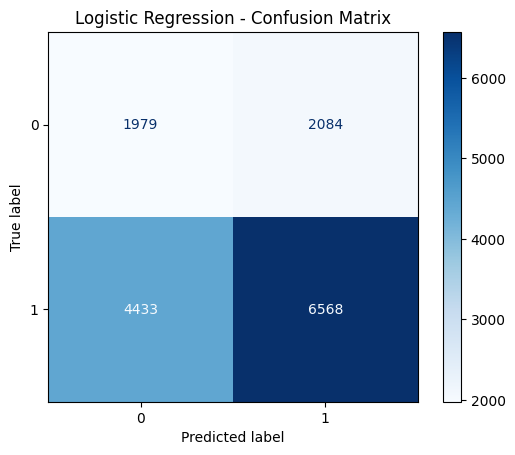

In [73]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap='Blues'
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## 8.4 ROC Curve

The Receiver Operating Characteristic (ROC) curve illustrates the model's ability to distinguish between churned and non-churned customers across different classification thresholds.

A higher Area Under the Curve (ROC-AUC) indicates better discriminative performance.

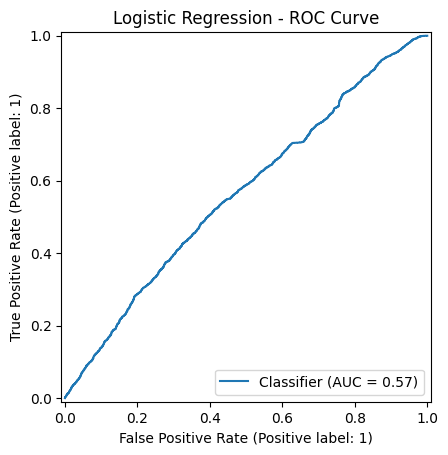

In [74]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr
)

plt.title("Logistic Regression - ROC Curve")
plt.show()

### Observation

Logistic Regression serves as a strong baseline model by providing interpretable predictions and estimated churn probabilities.

The evaluation metrics obtained from this model will serve as a benchmark for comparison with more advanced machine learning algorithms such as Random Forest and XGBoost.

# 9. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Unlike Logistic Regression, Random Forest can capture complex non-linear relationships and interactions between features. Since tree-based models are not sensitive to feature scaling, the original training data is used.

To account for class imbalance, the model is trained using `class_weight='balanced'`.

In [75]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 9.1 Generate Predictions

The trained Random Forest model is used to predict customer churn on the testing dataset.

Both predicted class labels and churn probabilities are generated for model evaluation.

In [76]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

## 9.2 Evaluate Random Forest

The Random Forest model is evaluated using several performance metrics, including Precision, Recall, F1-Score, and ROC-AUC.

These metrics provide a comprehensive assessment of the model's ability to correctly identify churned customers while minimizing false predictions.

In [77]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_rf))

print("ROC-AUC Score:",
      roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.81      0.58      0.67      4063
           1       0.86      0.95      0.90     11001

    accuracy                           0.85     15064
   macro avg       0.83      0.76      0.79     15064
weighted avg       0.84      0.85      0.84     15064

ROC-AUC Score: 0.8863914168141204


## 9.3 Confusion Matrix

The confusion matrix visualizes the classification results by comparing predicted churn labels with the actual customer status.

It highlights correctly classified customers as well as false positives and false negatives.

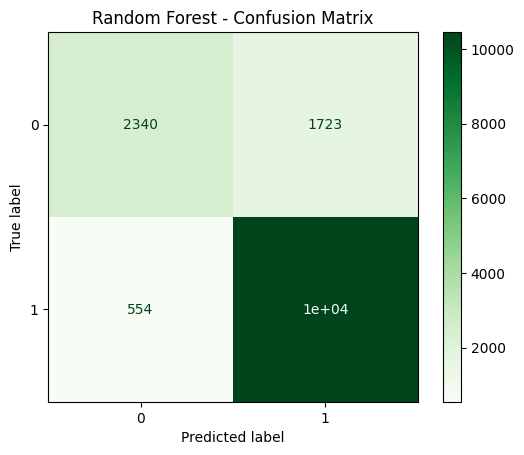

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap='Greens'
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

## 9.4 ROC Curve

The ROC curve illustrates the trade-off between the True Positive Rate and False Positive Rate across different decision thresholds.

The ROC-AUC score summarizes the model's overall ability to distinguish between churned and active customers.

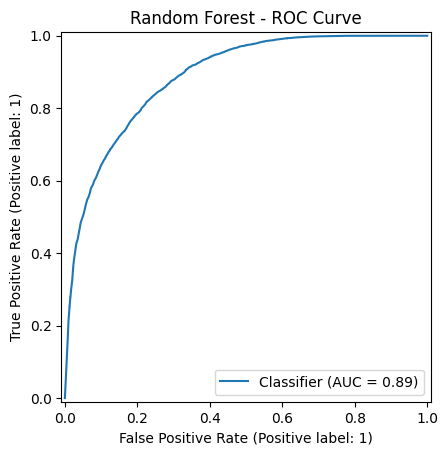

In [79]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("Random Forest - ROC Curve")
plt.show()

## 9.5 Feature Importance

Random Forest estimates the relative importance of each feature based on how much it contributes to reducing impurity across all decision trees.

This provides an initial understanding of which customer characteristics have the greatest influence on churn prediction.

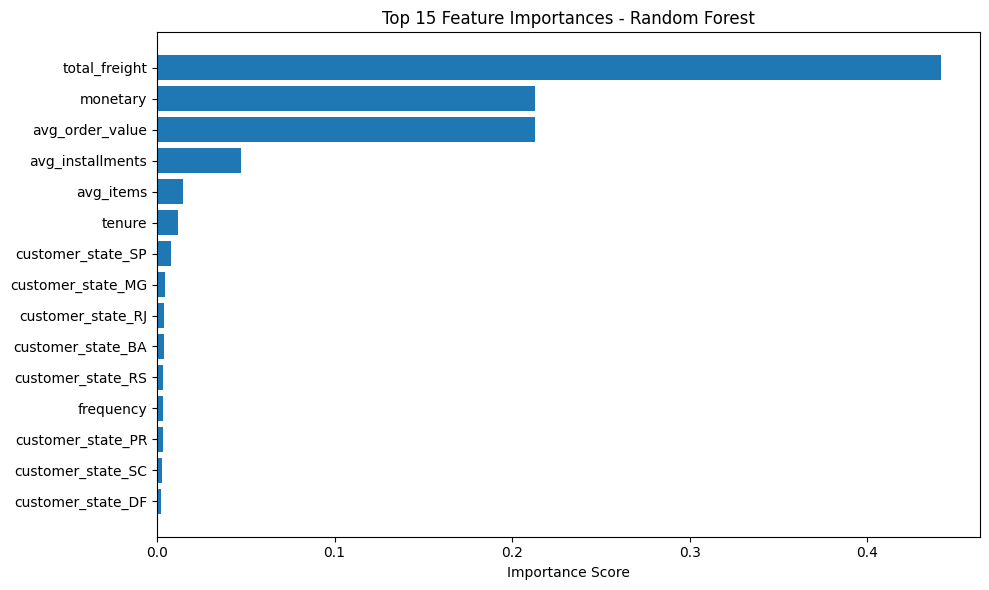

In [80]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'][:15][::-1],
    feature_importance['Importance'][:15][::-1]
)

plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()

### Observation

Random Forest captures complex patterns in customer behavior and provides feature importance scores that highlight the variables most influential in predicting churn.

Comparing its performance with Logistic Regression helps determine whether modeling non-linear relationships improves predictive accuracy.

# 10. XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm based on gradient-boosted decision trees. It is widely used for structured data problems due to its high predictive performance and ability to model complex relationships.

Since the dataset is imbalanced, the `scale_pos_weight` parameter is used to assign appropriate importance to the minority class during training.

In [81]:
from xgboost import XGBClassifier

# Calculate class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## 10.1 Generate Predictions

The trained XGBoost model is used to predict customer churn on the testing dataset.

Both predicted class labels and churn probabilities are generated for evaluation.

In [82]:
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

## 10.2 Evaluate XGBoost

The model is evaluated using multiple classification metrics to measure its ability to correctly identify churned customers.

Special attention is given to Precision, Recall, F1-Score, and ROC-AUC since these metrics provide a better assessment for imbalanced datasets than accuracy alone.

In [83]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC Score:",
      roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.62      0.78      0.69      4063
           1       0.91      0.83      0.86     11001

    accuracy                           0.81     15064
   macro avg       0.76      0.80      0.78     15064
weighted avg       0.83      0.81      0.82     15064

ROC-AUC Score: 0.887646611143108


## 10.3 Confusion Matrix

The confusion matrix summarizes the model's classification performance by comparing predicted labels with the actual churn outcomes.

It provides insight into correctly and incorrectly classified customers.

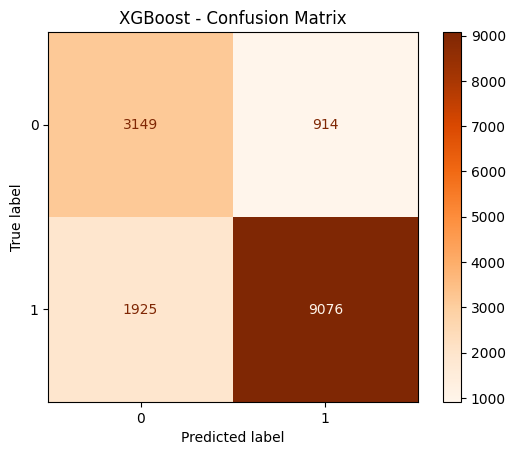

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap='Oranges'
)

plt.title("XGBoost - Confusion Matrix")
plt.show()

## 10.4 ROC Curve

The ROC curve illustrates the model's ability to distinguish between churned and non-churned customers over various classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's discriminative performance.

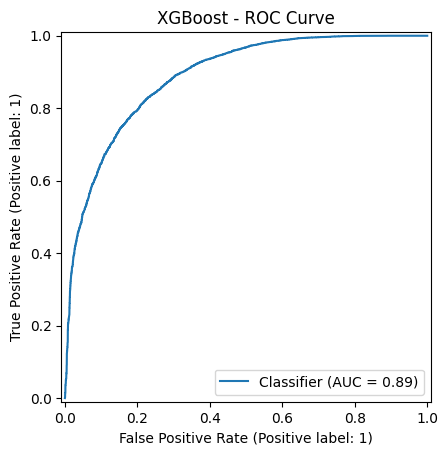

In [85]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.title("XGBoost - ROC Curve")
plt.show()

## 10.5 Feature Importance

XGBoost provides feature importance scores that indicate the contribution of each feature to the model's predictions.

These scores help identify the customer characteristics that most strongly influence churn prediction.

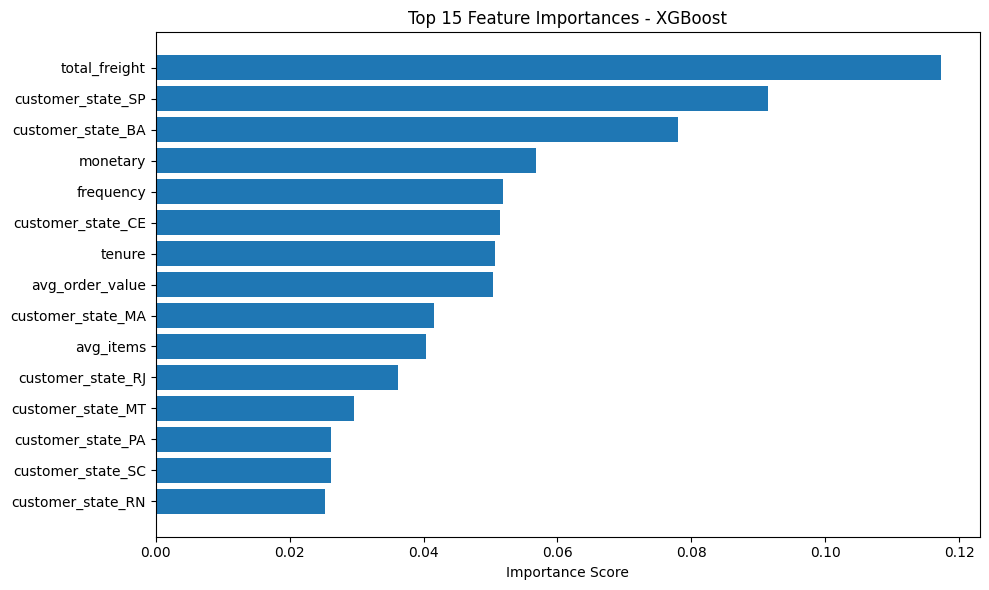

In [86]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_xgb['Feature'][:15][::-1],
    feature_importance_xgb['Importance'][:15][::-1]
)

plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances - XGBoost")

plt.tight_layout()
plt.show()

### Observation

XGBoost leverages gradient boosting to capture complex interactions between customer features, often achieving higher predictive performance than simpler models.

The feature importance analysis highlights the variables that contribute most to churn prediction and provides additional insight into customer behavior.

# 11. Model Comparison

Three machine learning models were trained and evaluated for customer churn prediction:

- Logistic Regression
- Random Forest
- XGBoost

Each model is compared using multiple evaluation metrics instead of relying solely on accuracy.

Since the dataset is imbalanced, Precision, Recall, F1-Score, and ROC-AUC provide a more reliable assessment of predictive performance.

## 11.1 Calculate Evaluation Metrics

The evaluation metrics for each model are collected into a single table to facilitate comparison and identify the best-performing model.

In [87]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.567379,0.759131,0.597037,0.668397,0.565459
1,Random Forest,0.848845,0.858422,0.949641,0.901731,0.886391
2,XGBoost,0.811537,0.908509,0.825016,0.864752,0.887647


## 11.2 Model Performance Comparison

The table below summarizes the predictive performance of all three machine learning models.

The best-performing model will be selected for explainability analysis and deployment.

In [88]:
results = results.sort_values(
    by="ROC-AUC",
    ascending=False
)

results.style.background_gradient(
    cmap="Greens",
    subset=["Accuracy","Precision","Recall","F1 Score","ROC-AUC"]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.811537,0.908509,0.825016,0.864752,0.887647
1,Random Forest,0.848845,0.858422,0.949641,0.901731,0.886391
0,Logistic Regression,0.567379,0.759131,0.597037,0.668397,0.565459


## 11.3 Visual Comparison of Model Performance

A bar chart provides a visual comparison of the evaluation metrics across all trained models.

This makes it easier to identify strengths and weaknesses of each algorithm.

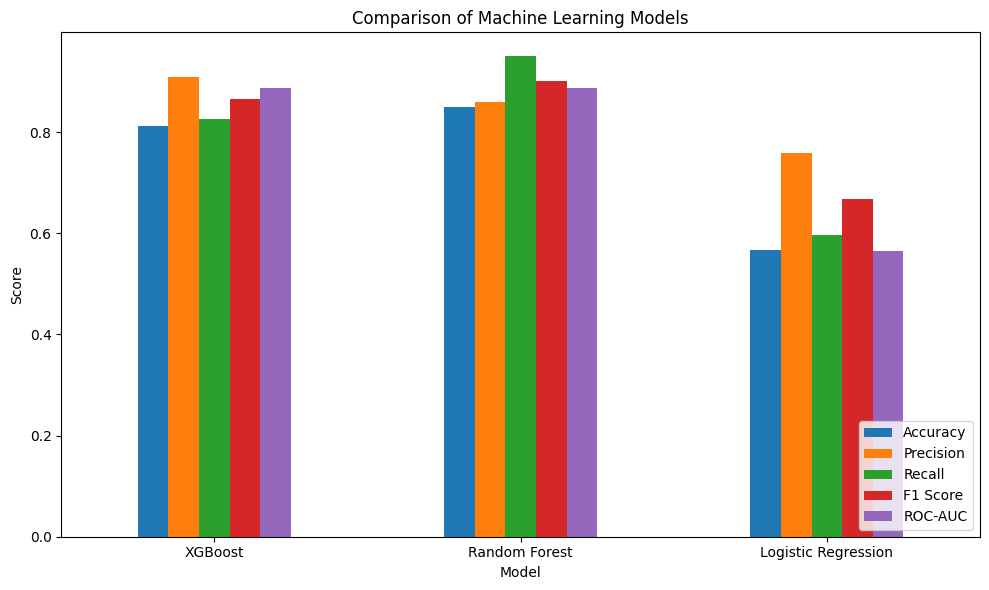

In [89]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

results_plot = results.set_index("Model")

results_plot[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Score")
plt.title("Comparison of Machine Learning Models")
plt.xticks(rotation=0)

plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 11.4 Best Model Selection

The model with the highest ROC-AUC score is selected as the final model for deployment.

ROC-AUC is chosen because it measures the model's ability to distinguish between churned and non-churned customers across all classification thresholds, making it particularly suitable for imbalanced classification problems.

In [90]:
best_model = results.iloc[0]["Model"]

print("Best Model:", best_model)

Best Model: XGBoost


### Observation

The comparison demonstrates that different machine learning algorithms perform differently on the churn prediction task.

The model with the highest ROC-AUC score provides the best balance between identifying churned customers and minimizing incorrect predictions. This model will be selected for the next stage of the project, where its predictions will be interpreted using SHAP and prepared for deployment.

In [91]:
import os

os.makedirs("../models", exist_ok=True)

In [93]:
import joblib

# Save all trained models
joblib.dump(log_reg, "../models/logistic_regression.pkl")
joblib.dump(rf, "../models/random_forest.pkl")
joblib.dump(xgb, "../models/xgb_model.pkl")

# Save preprocessing objects
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(X.columns.tolist(), "../models/feature_columns.pkl")

print("✅ All models saved successfully!")

✅ All models saved successfully!
